# AnchorStrategy Developer Guide

**Audience:** New developers joining the Arbiter project.

This notebook walks through the AnchorStrategy — a scoring strategy that prices
Kalshi economic indicator contracts using external probability anchors from FRED
data. We cover:

1. **The Problem** — Why market prices for economic releases can be mispriced
2. **The Math** — How we compute P(X > K) from FRED surprise history
3. **Data Pipeline** — How FRED data flows into the strategy
4. **Optimizations** — Three improvements that took Brier from 0.126 → 0.052
5. **Backtest Results** — Walk-forward evaluation on 1300+ settled contracts
6. **Production Wiring** — How it all fits into the ScanPipeline

---
## 1. The Problem

Kalshi lists binary contracts on economic releases. For example:

- **KXCPI-26JAN-T0.003** → "Will January 2026 CPI MoM change exceed 0.3%?"
- **KXPAYROLLS-26FEB-T200** → "Will February 2026 nonfarm payrolls exceed 200K?"

Each contract has a YES price (market's implied probability). The market can
misprice these because:

- **Thin liquidity** — economic indicator contracts trade less volume than political markets
- **No model-driven market makers** — most participants rely on gut feel
- **Information lag** — FRED publishes data that is publicly available but not priced in

Our approach: compute an **anchor probability** from FRED's historical surprise
distribution and flag contracts where the market price deviates significantly.

---
## 2. The Math

For a given economic indicator (e.g., CPI MoM), we model the actual release value as:

$$X \sim \mathcal{N}(\mu, \sigma^2)$$

where:
- **μ** = naive consensus forecast (prior value or 4-week moving average)
- **σ** = historical surprise volatility (exponentially weighted, winsorized)

For a contract with threshold K (e.g., "CPI > 0.3%"):

$$P(X > K) = 1 - \Phi\left(\frac{K - \mu}{\sigma}\right)$$

An opportunity exists when:

$$\text{anchor\_prob} - \text{market\_price} - \text{fee\_rate} > 0$$

Let's see this in code:

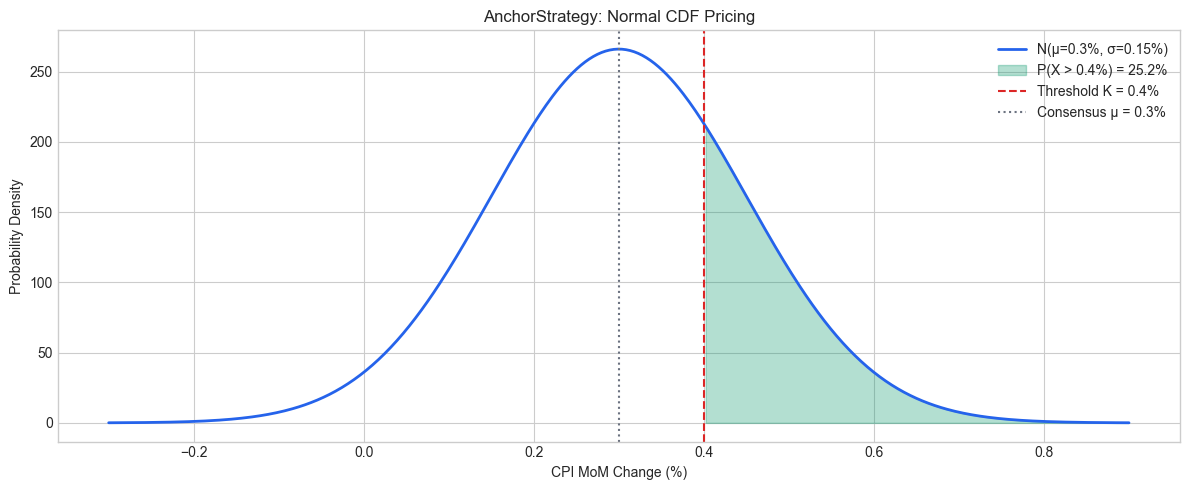

Anchor probability P(CPI > 0.4%) = 0.252 (25.2%)
If market prices this at 8¢: edge = 0.252 - 0.08 - 0.01 = 0.162


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Example: CPI MoM change
mu = 0.003     # consensus: 0.3% MoM
sigma = 0.0015  # historical surprise volatility

# The distribution of actual CPI values
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
pdf = norm.pdf(x, loc=mu, scale=sigma)

# Kalshi threshold: "Will CPI exceed 0.4%?"
K = 0.004  # 0.4%

fig, ax = plt.subplots()
ax.plot(x * 100, pdf, color="#2563eb", linewidth=2, label=f"N(μ={mu*100:.1f}%, σ={sigma*100:.2f}%)")
ax.fill_between(x[x > K] * 100, pdf[x > K], alpha=0.3, color="#059669", label=f"P(X > {K*100:.1f}%) = {norm.sf(K, mu, sigma):.1%}")
ax.axvline(K * 100, color="#dc2626", linestyle="--", linewidth=1.5, label=f"Threshold K = {K*100:.1f}%")
ax.axvline(mu * 100, color="#6b7280", linestyle=":", linewidth=1.5, label=f"Consensus μ = {mu*100:.1f}%")
ax.set_xlabel("CPI MoM Change (%)")
ax.set_ylabel("Probability Density")
ax.set_title("AnchorStrategy: Normal CDF Pricing")
ax.legend()
plt.tight_layout()
plt.show()

# The anchor probability
anchor_prob = norm.sf(K, loc=mu, scale=sigma)
print(f"Anchor probability P(CPI > 0.4%) = {anchor_prob:.3f} ({anchor_prob:.1%})")
print(f"If market prices this at 8¢: edge = {anchor_prob:.3f} - 0.08 - 0.01 = {anchor_prob - 0.08 - 0.01:.3f}")

In [2]:
# How this maps to the codebase:
from arbiter.scoring.anchor import compute_anchor_prob, extract_threshold

# Step 1: Parse Kalshi ticker → (group_key, threshold)
parsed = extract_threshold("KXCPI-26JAN-T0.003")
print(f"Parsed: {parsed}")
# → ('KXCPI-26JAN', 0.003)

# Step 2: Compute P(X > threshold)
prob = compute_anchor_prob(threshold=0.004, mu=0.003, sigma=0.0015)
print(f"P(X > 0.004) = {prob:.4f}")

# Step 3: Check for mispricing
market_price = 0.08
fee_rate = 0.01
ev = prob - market_price - fee_rate
print(f"EV = {prob:.3f} - {market_price:.2f} - {fee_rate:.2f} = {ev:.3f}")
print(f"→ {'OPPORTUNITY' if ev > 0 else 'No trade'}")

Parsed: ('KXCPI-26JAN', 0.003)
P(X > 0.004) = 0.2525
EV = 0.252 - 0.08 - 0.01 = 0.162
→ OPPORTUNITY


---
## 3. Data Pipeline

The data flows through three layers:

```
FRED API → fetch_fred_data.py → data/features/fred/{indicator}.json
                                         ↓
                              FREDSurpriseProvider.load()
                                         ↓
                                 FeatureSet(mu, sigma)
                                         ↓
                              AnchorStrategy.score()
                                         ↓
                               ScoredOpportunity[]
```

### Indicator Registry

Each economic series is registered in `arbiter/data/indicators.py` with:
- **fred_series** — the FRED series ID (e.g., `CPIAUCSL`)
- **transform** — how to convert raw values (`level`, `mom_pct`, `mom_change`, `yoy_pct`)
- **consensus_method** — how to estimate μ (`prior_value` or `moving_average_4w`)
- **recency_halflife** — exponential decay for σ weighting
- **threshold_scale** — converts Kalshi percentage-point thresholds to FRED decimal units

In [3]:
from arbiter.data.indicators import INDICATORS
import pandas as pd

# Show the indicator registry
rows = []
for iid, config in INDICATORS.items():
    rows.append({
        "Kalshi Series": iid,
        "FRED Series": config.fred_series,
        "Transform": config.transform,
        "Consensus": config.consensus_method,
        "Halflife": config.recency_halflife,
        "Scale": config.threshold_scale,
    })

pd.DataFrame(rows).set_index("Kalshi Series")

,FRED Series,Transform,Consensus,Halflife,Scale
Kalshi Series,,,,,
KXJOBLESSCLAIMS,ICSA,level,moving_average_4w,52,1.000
KXCPI,CPIAUCSL,mom_pct,prior_value,24,0.010
KXCPIYOY,CPIAUCSL,yoy_pct,prior_value,24,0.010
KXCPICOREYOY,CPILFESL,yoy_pct,prior_value,24,0.010
KXPAYROLLS,PAYEMS,mom_change,prior_value,24,0.001


In [4]:
# Example: Load the FRED surprise cache for CPI
import json
from pathlib import Path

import arbiter as _pkg
DATA_DIR = Path(_pkg.__file__).parent.parent / "data" / "features" / "fred"

cpi_path = DATA_DIR / "KXCPI.json"
if cpi_path.exists():
    with open(cpi_path) as f:
        cpi_data = json.load(f)
    
    obs = cpi_data["observations"]
    print(f"FRED series: {cpi_data['series']}")
    print(f"Transform: {cpi_data['transform']}")
    print(f"Observations: {len(obs)}")
    print(f"Current consensus (μ): {cpi_data['current_consensus']:.6f}")
    print(f"\nLast 5 observations:")
    for o in obs[-5:]:
        print(f"  {o['date']}: actual={o['actual']:.6f}  consensus={o['consensus']:.6f}  surprise={o['surprise']:+.6f}")
else:
    print(f"No FRED cache at {cpi_path}")
    print("Run: python scripts/fetch_fred_data.py KXCPI")

FRED series: CPIAUCSL
Transform: mom_pct
Observations: 946
Current consensus (μ): 0.002978

Last 5 observations:
  2025-08-01: actual=0.003483  consensus=0.002284  surprise=+0.001199
  2025-09-01: actual=0.002951  consensus=0.003483  surprise=-0.000532
  2025-11-01: actual=0.002523  consensus=0.002951  surprise=-0.000428
  2025-12-01: actual=0.002978  consensus=0.002523  surprise=+0.000455
  2026-01-01: actual=0.001708  consensus=0.002978  surprise=-0.001269


In [5]:
# How FREDSurpriseProvider computes sigma
from arbiter.data.providers.fred import FREDSurpriseProvider

provider = FREDSurpriseProvider(data_dir=str(DATA_DIR))
fs = provider.load("KXCPI")
if fs:
    print(f"Provider: {fs.provider}")
    print(f"μ (current consensus): {fs.anchor_mu:.6f}")
    print(f"σ (surprise volatility): {fs.anchor_sigma:.6f}")
    print(f"\nThis means: the FRED model expects CPI MoM to be ~{fs.anchor_mu*100:.2f}%,")
    print(f"with a standard deviation of ~{fs.anchor_sigma*100:.3f}% from historical surprises.")
else:
    print("No FRED data — run scripts/fetch_fred_data.py")

Provider: fred
μ (current consensus): 0.002978
σ (surprise volatility): 0.002111

This means: the FRED model expects CPI MoM to be ~0.30%,
with a standard deviation of ~0.211% from historical surprises.


---
## 4. Three Optimizations

The baseline model (raw σ, no calibration) achieved 88.5% directional accuracy
and Brier score 0.126 on 1300+ settled contracts. Three optimizations improved
Brier to 0.052 (58% improvement):

| Step | Change | Brier | Dir Acc |
|------|--------|-------|---------|
| 1. Baseline | Raw σ, no calibration | 0.1261 | 88.5% |
| 2. Std-clipped σ | Clip surprises at ±3 sample-std | 0.1145 | 88.5% |
| 3. MAD-winsorized σ | MAD-based outlier clipping (production) | 0.1043 | 88.5% |
| 4. + Isotonic calibration | Per-series IsotonicRegression | **0.0524** | **92.7%** |

### Optimization 1: Winsorized σ (Outlier Removal)

**Problem:** COVID-era data spikes inflate σ dramatically:
- Payrolls: typical surprise ±100K, COVID spike = -17,000K → σ inflated 5x
- Jobless Claims: typical ±15K, COVID spike = +3,000K → σ inflated 4x

An inflated σ makes the Gaussian too wide, pushing anchor probabilities toward 0.5
("I don't know"), destroying the model's ability to identify mispricings.

**Fix:** MAD-based winsorization. Uses the Median Absolute Deviation (robust to
outliers) instead of standard deviation to define the clipping boundary:

```python
median = statistics.median(values)
mad = statistics.median(abs(v - median) for v in values)
cap = 3.0 * 1.4826 * mad   # 1.4826 converts MAD to σ-equivalent
values = [clip(v, median - cap, median + cap) for v in values]
```

Why MAD > simple std for clipping? Because the outliers themselves inflate the std
that defines the clip boundary — a circular dependency. MAD is robust to outliers.

Raw σ:             5126.4
Winsorized σ:       154.9
Reduction:     97%


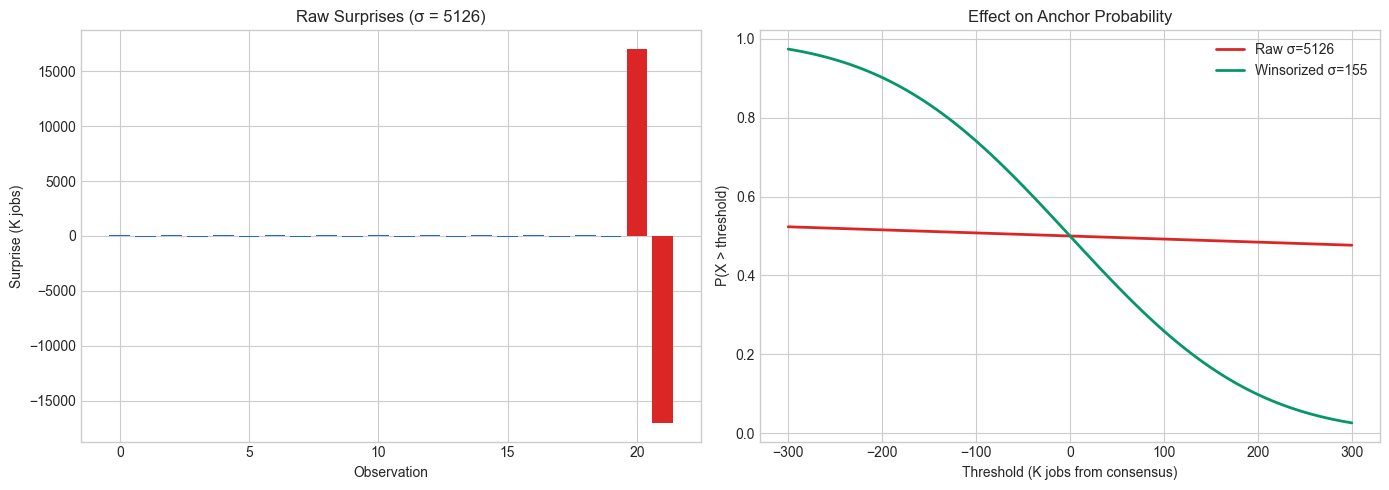


→ Winsorized σ produces sharper probability estimates (steeper S-curve)
  instead of the flat 'everything is ~50%' from inflated σ.


In [6]:
from arbiter.data.providers.fred import compute_sigma

# Simulate Payrolls-like data with COVID outliers
normal = [100, -80, 120, -90, 70, -110, 80, -60, 90, -100,
          110, -70, 130, -80, 60, -120, 90, -50, 100, -90]
outliers = [17000, -17000]  # COVID
surprises = [float(x) for x in normal + outliers]

sigma_raw = compute_sigma(surprises, halflife=None, winsorize=False)
sigma_win = compute_sigma(surprises, halflife=None, winsorize=True)

print(f"Raw σ:         {sigma_raw:>10.1f}")
print(f"Winsorized σ:  {sigma_win:>10.1f}")
print(f"Reduction:     {(sigma_raw - sigma_win) / sigma_raw:.0%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw surprises with outliers
ax = axes[0]
ax.bar(range(len(surprises)), surprises, color=["#dc2626" if abs(s) > 1000 else "#2563eb" for s in surprises])
ax.set_title(f"Raw Surprises (σ = {sigma_raw:.0f})")
ax.set_ylabel("Surprise (K jobs)")
ax.set_xlabel("Observation")

# Right: Impact on anchor probability
ax2 = axes[1]
thresholds = np.linspace(-300, 300, 100)  # K jobs from mean
probs_raw = norm.sf(thresholds, loc=0, scale=sigma_raw)
probs_win = norm.sf(thresholds, loc=0, scale=sigma_win)
ax2.plot(thresholds, probs_raw, color="#dc2626", linewidth=2, label=f"Raw σ={sigma_raw:.0f}")
ax2.plot(thresholds, probs_win, color="#059669", linewidth=2, label=f"Winsorized σ={sigma_win:.0f}")
ax2.set_xlabel("Threshold (K jobs from consensus)")
ax2.set_ylabel("P(X > threshold)")
ax2.set_title("Effect on Anchor Probability")
ax2.legend()

plt.tight_layout()
plt.show()
print("\n→ Winsorized σ produces sharper probability estimates (steeper S-curve)")
print("  instead of the flat 'everything is ~50%' from inflated σ.")

### Optimization 2: Exponential Recency Weighting

**Problem:** Economic volatility regimes change. A σ computed from 20 years of data
weights 2005 equally with 2025, even though recent surprise patterns are more relevant.

**Fix:** Exponential decay weights with a configurable halflife:

```python
decay = log(2) / halflife
weights[i] = exp(-decay * (n - 1 - i))  # most recent = weight 1.0
```

Halflife is set per-indicator in the registry:
- **Jobless Claims (ICSA)**: halflife=52 (weekly data, ~1 year lookback)
- **CPI/Payrolls**: halflife=24 (monthly data, ~2 year lookback)

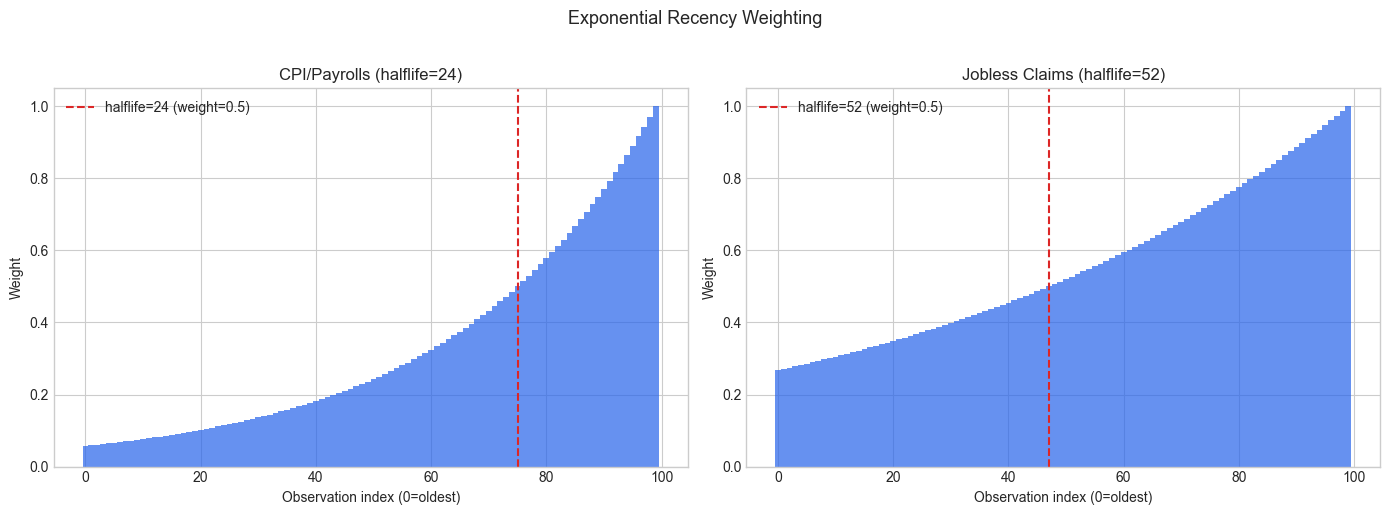

→ Recent observations dominate the σ estimate, reducing sensitivity to old regime shifts.


In [7]:
import math

# Visualize the exponential decay weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, halflife, title in [
    (axes[0], 24, "CPI/Payrolls (halflife=24)"),
    (axes[1], 52, "Jobless Claims (halflife=52)"),
]:
    n = 100
    decay = math.log(2) / halflife
    weights = [math.exp(-decay * (n - 1 - i)) for i in range(n)]
    ax.bar(range(n), weights, color="#2563eb", alpha=0.7, width=1.0)
    ax.axvline(n - 1 - halflife, color="#dc2626", linestyle="--", label=f"halflife={halflife} (weight=0.5)")
    ax.set_xlabel("Observation index (0=oldest)")
    ax.set_ylabel("Weight")
    ax.set_title(title)
    ax.legend()

plt.suptitle("Exponential Recency Weighting", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print("→ Recent observations dominate the σ estimate, reducing sensitivity to old regime shifts.")

### Optimization 3: Per-Series Isotonic Calibration

**Problem:** The Gaussian model systematically overestimates CPI probabilities (~7%
bias) and underestimates Payrolls (~6% bias). Each indicator's surprise distribution
has its own quirks (skewness, fat tails) that don't perfectly match the Gaussian.

**Fix:** Fit one `IsotonicRegression` per indicator series on historical
anchor_prob → actual_outcome pairs. This is a monotone, non-parametric calibration
that preserves the model's direction while correcting systematic bias.

```
fit_anchor_calibrators.py workflow:
1. Fetch settled markets from Kalshi for each indicator series
2. Walk-forward: for each settled contract, compute anchor_prob using only
   prior surprises (no look-ahead)
3. Fit IsotonicRegression: anchor_prob → actual YES/NO outcome
4. Save to models/anchor_calibrators.pkl
```

Why per-series (not pooled)? Pooled calibration lets CPI (1053 records) dominate
the learned calibration curve, worsening Payrolls bias.

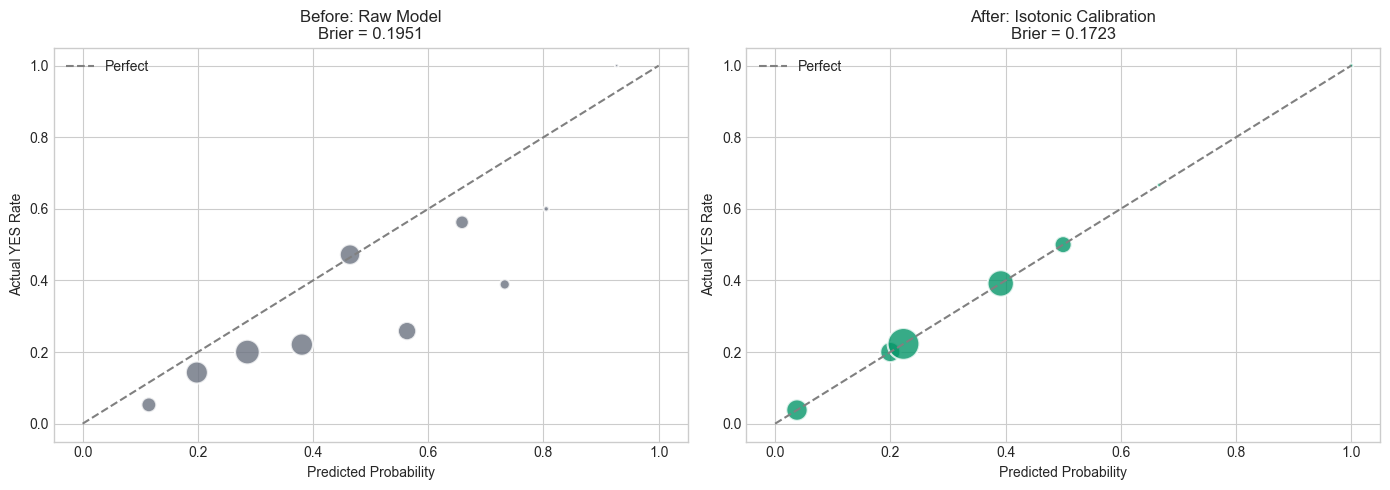

→ Isotonic regression pulls the calibration curve back toward the diagonal.
  It's monotone (preserves model ordering) and non-parametric (no assumptions).


In [8]:
# Demonstrate isotonic calibration on synthetic data
from sklearn.isotonic import IsotonicRegression

np.random.seed(42)

# Simulate: model predicts probabilities that are systematically overconfident
n = 500
true_probs = np.random.beta(2, 5, n)  # skewed toward low probabilities
model_probs = true_probs * 1.15 + 0.05  # systematic overestimate
model_probs = np.clip(model_probs, 0, 1)
outcomes = np.random.binomial(1, true_probs)

# Fit isotonic regression
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(model_probs, outcomes)
calibrated = iso.predict(model_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title, color in [
    (axes[0], model_probs, "Before: Raw Model", "#6b7280"),
    (axes[1], calibrated, "After: Isotonic Calibration", "#059669"),
]:
    bins = pd.cut(probs, bins=10)
    df_cal = pd.DataFrame({"prob": probs, "outcome": outcomes, "bin": bins})
    cal = df_cal.groupby("bin", observed=True).agg(mean_prob=("prob", "mean"), actual=("outcome", "mean"), n=("outcome", "count"))
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Perfect")
    ax.scatter(cal["mean_prob"], cal["actual"], s=cal["n"] * 3, c=color, alpha=0.8, edgecolors="white", linewidth=1.5)
    brier = ((probs - outcomes) ** 2).mean()
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Actual YES Rate")
    ax.set_title(f"{title}\nBrier = {brier:.4f}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()
print("→ Isotonic regression pulls the calibration curve back toward the diagonal.")
print("  It's monotone (preserves model ordering) and non-parametric (no assumptions).")

---
## 5. Backtest Results

The walk-forward backtest evaluates the model on 1300+ historically settled
Kalshi contracts across 4 indicator series (CPI, CPI YoY, Core CPI YoY, Payrolls).

For each settled contract:
1. Parse the threshold from the ticker
2. Find the FRED observation at settlement date
3. Compute σ from **prior** surprises only (no look-ahead)
4. Compute anchor_prob = P(X > threshold × scale)
5. Compare to the actual YES/NO outcome

Key metrics:
- **Brier score** — mean squared error of probability estimates (lower = better, 0.25 = naive)
- **Directional accuracy** — did the model correctly predict YES (>50%) or NO (<50%)?

Results (tuned model = MAD-σ + isotonic calibration):

| Series | n | Raw Brier | Tuned Brier | Δ |
|--------|---|-----------|-------------|---|
| KXCPI | 388 | 0.0866 | 0.0432 | -0.0434 |
| KXCPICOREYOY | 292 | 0.0839 | 0.0394 | -0.0445 |
| KXCPIYOY | 373 | 0.1097 | 0.0509 | -0.0588 |
| KXPAYROLLS | 265 | 0.1453 | 0.0821 | -0.0631 |
| **Overall** | **1318** | **0.1043** | **0.0524** | **-0.0519** |

Overall directional accuracy: **92.7%** (tuned) vs 88.5% (baseline).

---
## 6. Production Wiring

### Architecture

```
ScanPipeline
  ├── strategies: [IndicatorRouter]
  │     ├── indicator contracts (KXCPI, KXPAYROLLS, ...) → [ConsistencyStrategy, AnchorStrategy]
  │     └── other contracts → [YesOnlyEVStrategy]
  ├── clients: [KalshiClient, PolymarketClient]
  ├── estimator: LGBMEstimator
  └── channels: [DiscordChannel]
```

**Key design decision:** When anchor providers are available for economic indicator
series, `build_default_strategies()` **excludes** the LightGBM-based EVStrategy
from those contracts. Why? The LightGBM model has no knowledge of the current
release cycle — it can't know what FRED data will be. AnchorStrategy is the
correct pricer for economic releases.

Routing uses `IndicatorRouter`, which splits contracts by ticker prefix (e.g.
`KXCPI` from `KXCPI-26JAN-T0.4`) against the `INDICATORS` registry. This
replaced `CategoryRouter` because Kalshi's API does not populate a `category` field.

### Strategy ABC

All strategies implement the same interface:

```python
class Strategy(ABC):
    async def score(
        self,
        contracts: list[Contract],
        estimator: ProbabilityEstimator,
    ) -> list[ScoredOpportunity]: ...
```

The `AnchorStrategy` ignores the estimator entirely — it uses its own μ/σ from
FRED providers. But it conforms to the Strategy ABC so it can be composed with
other strategies via `IndicatorRouter`.

In [ ]:
# How to build the production strategy stack
from arbiter.scoring.strategy import build_default_strategies, AnchorStrategy
from arbiter.data.providers.fred import FREDSurpriseProvider

# 1. Without anchor providers — just EV + Consistency
strategies_basic = build_default_strategies(fee_rate=0.01)
print("Basic (no anchor):")
for s in strategies_basic:
    print(f"  {s.name}")

# 2. With anchor providers + indicator routing
fred = FREDSurpriseProvider(data_dir=str(DATA_DIR))
strategies_full = build_default_strategies(
    fee_rate=0.01,
    anchor_providers=[fred],
    calibrators_path="models/anchor_calibrators.pkl" if Path("models/anchor_calibrators.pkl").exists() else None,
)
print("\nWith anchor + IndicatorRouter:")
for s in strategies_full:
    print(f"  {s.name}")
    if hasattr(s, '_indicator_strategies'):
        print(f"    indicator contracts → {[st.name for st in s._indicator_strategies]}")
        print(f"    other contracts → {[st.name for st in s._default]}")

### File Map

| File | Purpose |
|------|--------|
| `arbiter/data/indicators.py` | Indicator registry (series → FRED config) |
| `arbiter/data/providers/base.py` | FeatureSet dataclass, FeatureProvider protocol |
| `arbiter/data/providers/fred.py` | FREDSurpriseProvider (loads μ, computes σ) |
| `arbiter/scoring/anchor.py` | Core anchor math (extract_threshold, compute_anchor_prob, find_mispricings) |
| `arbiter/scoring/strategy.py` | AnchorStrategy + build_default_strategies + CategoryRouter |
| `scripts/fetch_fred_data.py` | Fetch FRED data → JSON cache |
| `scripts/fit_anchor_calibrators.py` | Train isotonic calibrators from settled history |
| `scripts/evaluate_anchor_calibration.py` | Offline calibration evaluation |
| `scripts/fetch_candlestick_prices.py` | Fetch pre-release entry prices for P&L sim |
| `scripts/backfill_outcomes.py` | Backfill MarketSnapshot outcomes from Kalshi settlements |

### Running the Full Pipeline

```bash
# 1. Fetch FRED data (requires FRED_API_KEY)
python scripts/fetch_fred_data.py

# 2. (Optional) Train isotonic calibrators
python scripts/fit_anchor_calibrators.py

# 3. Run the scanner with anchor strategy
make run  # ScanPipeline auto-detects FRED cache and adds AnchorStrategy

# 4. Evaluate calibration
python scripts/evaluate_anchor_calibration.py
python scripts/evaluate_anchor_calibration.py --live  # + DB predictions
```